In [1]:
%load_ext autoreload
%autoreload 2

# XTCAV Processing - Dark Reference

Let's make a new class for XTCAV data processing that collects some of the old code.
- Currently the xtcav and xtcav2 repositories are fairly different.  I've cloned xtcav2 from github, copied xtcav(1) from its source code on s3df at `/sdf/group/lcls/ds/ana/sw/conda1/inst/envs/ana-4.0.66-py3/lib/python3.9/site-packages/xtcav` (see `xtcav.__file__`), and pasted the utils code I wrote that uses xtcav(1) objects.
- The goal here is to begin to synthesize and simplify.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from utils import get_com_clean, get_plot_lims
import psana

# XTCAV Processor Class
from xtcav_processor import XTCAVProcessor
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

In [3]:
# Dark Reference Class

from past.utils import old_div

class XTCAVDarkReference(XTCAVProcessor):

    def __init__(self, data_source, max_shots=401, compute=True, env=None, preindex=False, iteration='frames', verbose=True):
        """
        Parameters
        ----------
        data_source : a psana DataSource instance
            Must point to a dark run
        max_shots : integer
            Maximum number of camera frames to average
        compute : bool
            If true, compute the dark reference upon instantiation
        env : None or a psana.Env
            if None uses dataSouce.env()
        preindex : bool
            Toggles indexing events on instantiation. If True, loops through all
            events and determines which data types (ebeam, gas detector, XTCAV
            camera frame) are present for each event.
        iteration : string in ('all', 'good', 'frames'):
            Determines which data is traversed when using the shot iterator.
            'all' iterates over all shots. 'good' iterates over shots with all data
            present.  'frames' iterates over all data with XTCAV camera data present.
        verbose : bool
        """
        XTCAVProcessor.__init__(
            self,
            data_source=data_source,
            env=env,
            preindex=preindex,
            iteration=iteration,
            verbose=verbose
        )
        self._max_shots = max_shots
        self._dark_reference = None
        if compute:
            self.compute()
        pass

    @property
    def max_shots(self):
        return self._max_shots
    
    def compute(self):
        """ Calculate the dark reference
        """
        # setup
        ans = np.zeros(self.frameshape, dtype=np.float64)
        n = 0

        # loop
        for i,j,evt in self._progress(self.shot_iterator, desc="Calculating dark reference", total=self.max_shots):
            # set event and get camera image
            self.set_current_event(evt)
            im = self.frame

            # skip if empty image
            if im is None: 
                continue

            # add
            ans += im
            n += 1            

            #
            # if n % 5 == 0:
            #     sys.stdout.write('\r%.1f %% done, %d / %d' % (float(n) / self.parameters.max_shots*100, n, self.parameters.max_shots ))
            #     sys.stdout.flush()   

            # finish
            if n >= self.max_shots:
                break             

        # finish
        self._dark_reference=old_div(ans,n)
        
        # print       
        if self._verbose:
            #At the end of the program the total accumulator is saved 
            print('\nMaximum number of images processed\n') 
        
    @property
    def dark_reference(self):
        return self._dark_reference
            
    # def save(self):
    #     cp = CalibrationPaths(dataSource.env(), self.parameters.calibration_path)
    #     file = cp.newCalFileName(Cn.DB_FILE_NAME, self.parameters.validity_range[0], self.parameters.validity_range[1])
    #     self.save(file)

In [ ]:
xtdr = XTCAVDarkReference(get_datasource(75), max_shots=1000)

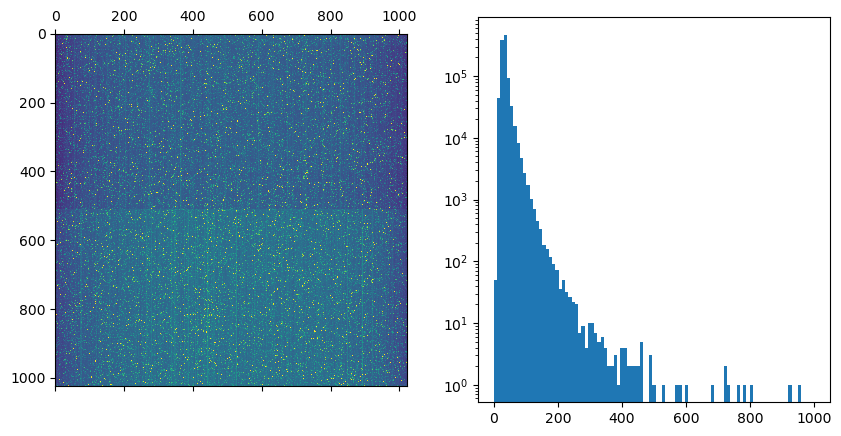

In [44]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(xtdr.dark_reference,vmin=0,vmax=1e2)
ax2.hist(xtdr.dark_reference.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

In [ ]:
XTCAVProcessor?

In [9]:
# Show the default behavior

runnum = 11

# Set up the data source
data_source=psana.DataSource("exp=cxil1037623:run=%d:idx"%runnum)

# Create the XTCAV processor
xtpr = XTCAVProcessor(data_source)

Setting up data run times...
Done.


Setting data source types...:   0%|          | 0/41024 [00:00<?, ?it/s]

Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


Showing good shot #1 at time index 228:


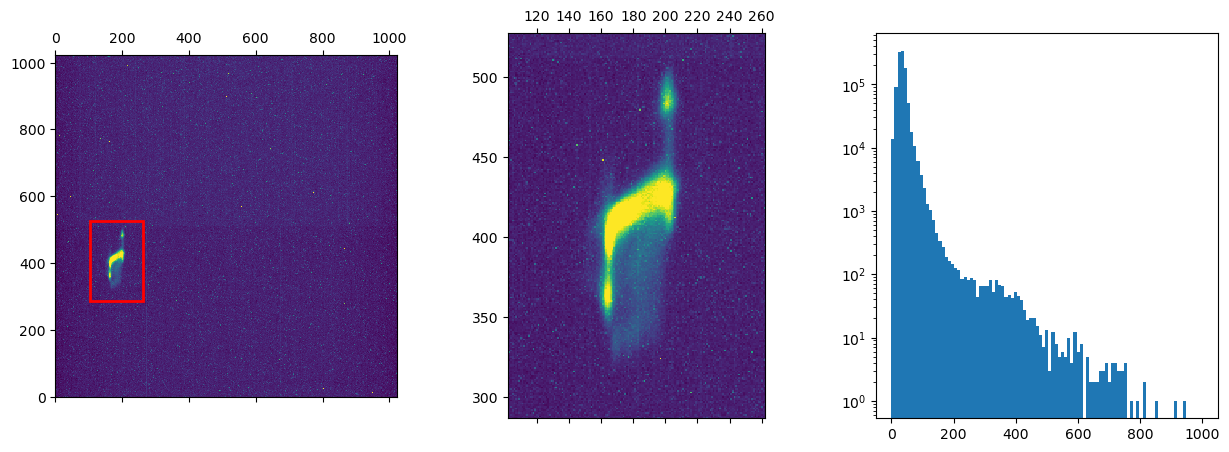

Showing good shot #2 at time index 229:


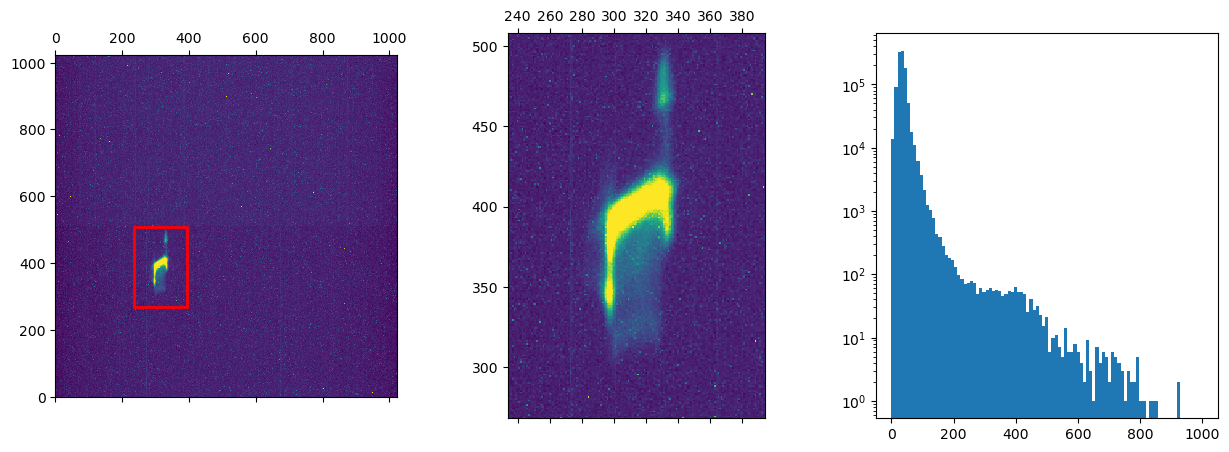

Showing good shot #3 at time index 230:


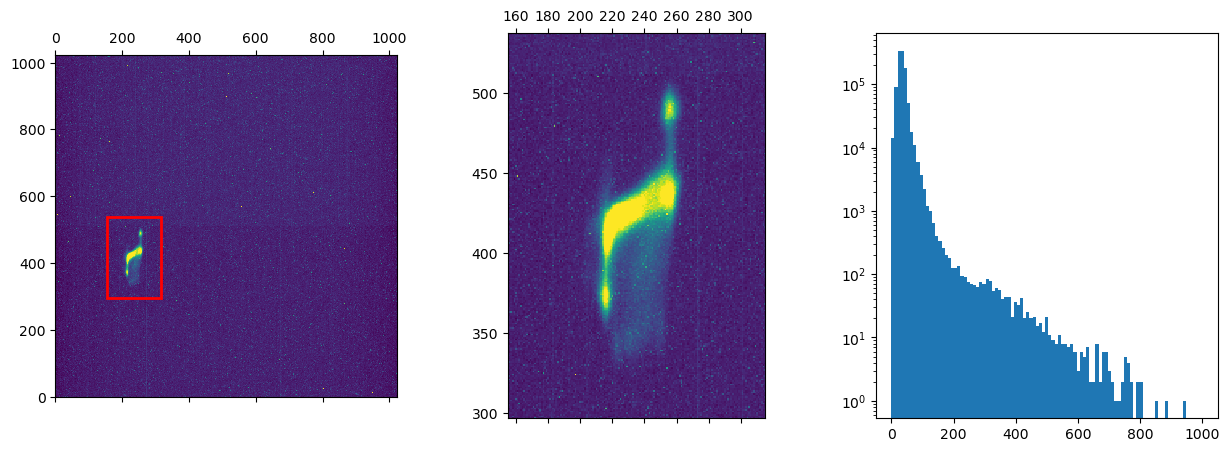

In [10]:
# Show a few shots

# params
n_shots_show = 3
fovs = Lx,Ly = 160,240

# loop
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get shot and image
    xtpr.set_current_event(evt)
    im = xtpr._rawimage

    try:
        # Get CoM for zoom-in
        com = get_com_clean(im)
    
        # Plot
        fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))
        # full field
        ax1.matshow(im, vmin=0,vmax=350)
        ax1.invert_yaxis()
        # zoom-in
        ax2.matshow(im, vmin=0,vmax=350)
        ax2.set_xlim(get_plot_lims(com[1],Lx))
        ax2.set_ylim(get_plot_lims(com[0],Ly))
        #ax2.set_aspect('equal')   
        # zoom rectangle
        xy = (com[1]-Lx/2,com[0]-Ly/2)
        rect = Rectangle((xy),Lx,Ly,lw=2,edgecolor='r',facecolor='none')
        ax1.add_patch(rect)
        # histogram
        ax3.hist(im.ravel(),bins=np.linspace(0,1000,100))
        ax3.set_yscale('log')
        plt.show()
    except TypeError:
        assert(im is None)
        print(f"Shot {i+1} is missing XTCAV camera data")

    # continue?
    if idx>=n_shots_show-1:
        break

Showing good shot #10 at time index 237:


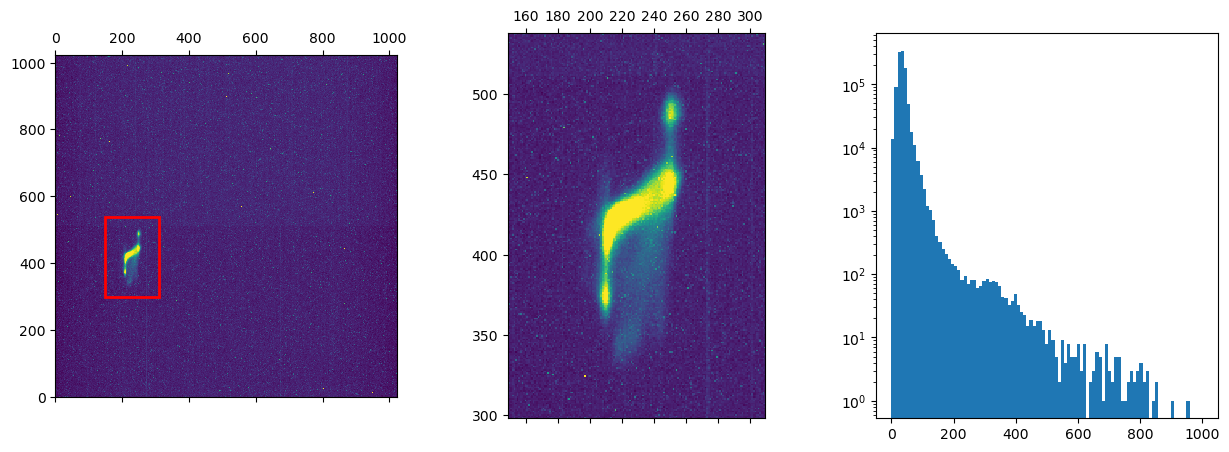

Showing good shot #11 at time index 238:


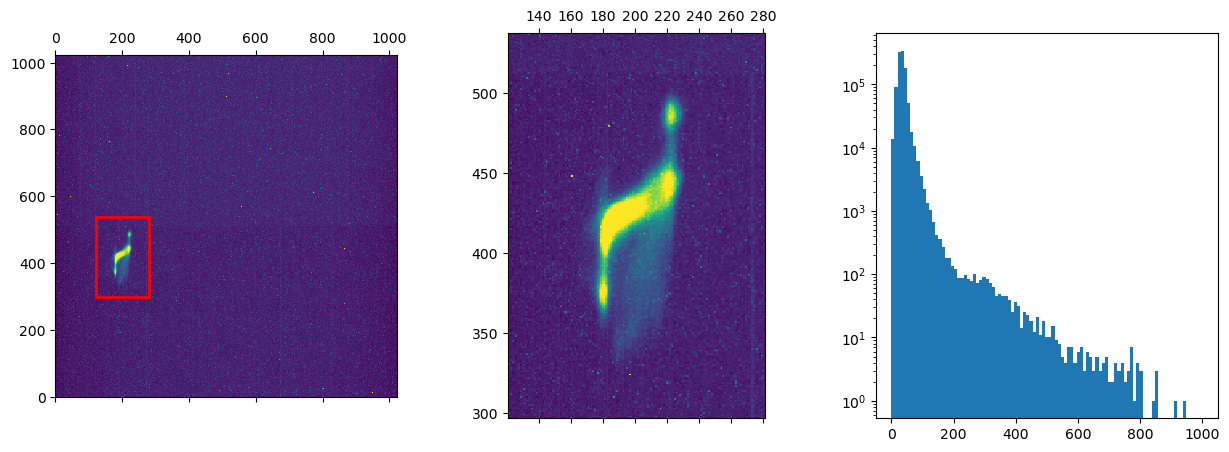

Showing good shot #12 at time index 239:


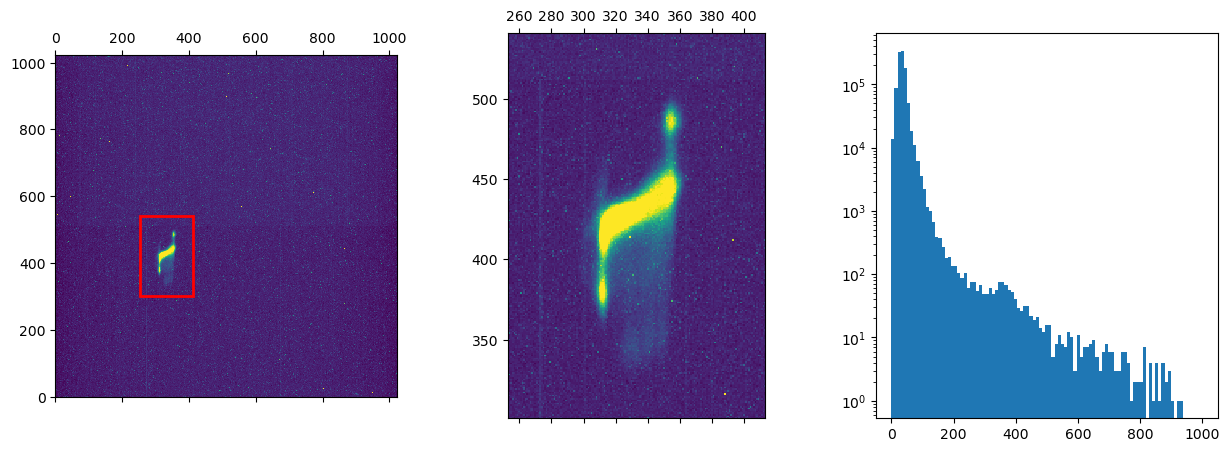

In [8]:
# continue from where we left off

# loop
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get shot and image
    xtpr.set_current_event(evt)
    im = xtpr._rawimage

    try:
        # Get CoM for zoom-in
        com = get_com_clean(im)
    
        # Plot
        fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))
        # full field
        ax1.matshow(im, vmin=0,vmax=350)
        ax1.invert_yaxis()
        # zoom-in
        ax2.matshow(im, vmin=0,vmax=350)
        ax2.set_xlim(get_plot_lims(com[1],Lx))
        ax2.set_ylim(get_plot_lims(com[0],Ly))
        #ax2.set_aspect('equal')   
        # zoom rectangle
        xy = (com[1]-Lx/2,com[0]-Ly/2)
        rect = Rectangle((xy),Lx,Ly,lw=2,edgecolor='r',facecolor='none')
        ax1.add_patch(rect)
        # histogram
        ax3.hist(im.ravel(),bins=np.linspace(0,1000,100))
        ax3.set_yscale('log')
        plt.show()
    except TypeError:
        assert(im is None)
        print(f"Shot {i+1} is missing XTCAV camera data")

    # continue?
    if idx>=n_shots_show-1:
        break

### Test resetting the iterator

In [16]:
# Loop to the end
# There are 41024 shots.

for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    if j%1000==0:
        print(f"Iterated to shot {j}.  Continuing...")
    pass
print('Done.')

Iterated to shot 1000.  Continuing...
Iterated to shot 2000.  Continuing...
Iterated to shot 3000.  Continuing...
Iterated to shot 4000.  Continuing...
Iterated to shot 5000.  Continuing...
Iterated to shot 6000.  Continuing...
Iterated to shot 7000.  Continuing...
Iterated to shot 8000.  Continuing...
Iterated to shot 9000.  Continuing...
Iterated to shot 10000.  Continuing...
Iterated to shot 11000.  Continuing...
Iterated to shot 12000.  Continuing...
Iterated to shot 13000.  Continuing...
Iterated to shot 14000.  Continuing...
Iterated to shot 15000.  Continuing...
Iterated to shot 16000.  Continuing...
Iterated to shot 17000.  Continuing...
Iterated to shot 18000.  Continuing...
Iterated to shot 19000.  Continuing...
Iterated to shot 20000.  Continuing...
Iterated to shot 21000.  Continuing...
Iterated to shot 22000.  Continuing...
Iterated to shot 23000.  Continuing...
Iterated to shot 24000.  Continuing...
Iterated to shot 25000.  Continuing...
Iterated to shot 26000.  Continuin

In [18]:
# Try iterating.  Should fail - iterator has not been reset.

print("Testing iterator reset. Nothing should print below except 'Done.' !")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Iterated to shot {j}.  Continuing...")
    print("This should not happen!! If this prints, the iterator has somehow been reset when it shouldn't have been!")
    if j>=5:
        break
    pass
print('Done.')

Testing iterator reset. Nothing should print below except 'Done.' !
Done.


In [20]:
# Now reset the iterator and try again.

xtpr.reset_shot_iterator()

print("Testing iterator reset. Now several iteration statements should print...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Iterated to shot {j}.  Continuing...")
    if i>=5:
        break
    pass
print('Done.')

Testing iterator reset. Now several iteration statements should print...
Iterated to shot 228.  Continuing...
Iterated to shot 229.  Continuing...
Iterated to shot 230.  Continuing...
Iterated to shot 231.  Continuing...
Iterated to shot 232.  Continuing...
Iterated to shot 233.  Continuing...
Done.


In [21]:
# Now try resetting to a different iterator type.

xtpr._set_iteration_type('all')
xtpr.reset_shot_iterator()

for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Iterated to shot {j}.  Continuing...")
    if i>=5:
        break
    pass
print('Done.')

Iterated to shot 0.  Continuing...
Iterated to shot 1.  Continuing...
Iterated to shot 2.  Continuing...
Iterated to shot 3.  Continuing...
Iterated to shot 4.  Continuing...
Iterated to shot 5.  Continuing...
Done.


In [23]:
xtpr._set_iteration_type('frames')
xtpr.reset_shot_iterator()

for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Iterated to shot {j}.  Continuing...")
    if i>=5:
        break
    pass
print('Done.')

Iterated to shot 228.  Continuing...
Iterated to shot 229.  Continuing...
Iterated to shot 230.  Continuing...
Iterated to shot 231.  Continuing...
Iterated to shot 232.  Continuing...
Iterated to shot 233.  Continuing...
Done.
